# Merge granules into full scans

TEMPO acquires a single east-west **scan** as a sequence of **granules** (the file token `S<scan>G<granule>`). All granules of one scan share a single scan number and represent contiguous strips of the scan footprint — together they cover the full instantaneous field of regard.

This notebook takes the per-granule outputs already produced under `../results/<year>/<month>/<day>/` and merges them by scan, writing one set of files per scan into `../results_scan/<year>/<month>/<day>/`.

**Per scan, three GIS layers + one raster are produced:**

| Output | How it is built |
|---|---|
| `rgb_S<scan>.tif` | `rasterio.merge.merge` of all granule GeoTIFFs |
| `S<scan>_clouds.shp` | Concatenation of all granule cloud shapefiles |
| `S<scan>_potential_shadows.shp` | Same, for PCSF |
| `S<scan>_actual_shadows.shp` | Same, for ACSF |

**Caveats** (see closing markdown for full discussion):
1. Each granule's GeoTIFF was written with a per-granule `from_bounds` affine, so pixel sizes differ slightly between granules. `rasterio.merge` resamples to the first source's resolution — this is acceptable for visualization but introduces small geometric distortion at granule seams.
2. Shapefiles are simply concatenated; we do not dissolve features across granule boundaries. A cloud that crosses a seam will appear as two adjacent polygons that touch but are not unioned.
3. We work from the already-processed per-granule outputs, not from raw L1B/L2 data. Doing this on the raw data would give better fidelity (single coherent CRS, no resampling), but is the next step — see `scripts/run_day.py` for the per-granule pipeline this builds on.

In [3]:
import os
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import rasterio
from rasterio.merge import merge

import fiona
from shapely.geometry import shape, mapping

In [4]:
# === Paths ===
RESULTS_DIR = Path("../results")
OUT_DIR     = Path("../results_scan")

# Suffixes that identify the three vector layers per granule
SHP_SUFFIXES = ["clouds", "potential_shadows", "actual_shadows"]

# Regex that picks scan/granule out of a TEMPO filename
SCAN_RE = re.compile(r"_S(\d{3})G(\d{2})")

OUT_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
def discover_scans(day_dir: Path) -> dict:
    """Group all rgb_*.tif files in a day directory by their scan number.

    Returns: {scan_str: [(granule_str, tif_path), ...]}, sorted by granule.
    """
    by_scan = defaultdict(list)
    for tif in day_dir.glob("rgb_TEMPO_RAD_L1_*.tif"):
        m = SCAN_RE.search(tif.name)
        if not m:
            print(f"  WARNING: unparseable filename, skipping: {tif.name}")
            continue
        scan, granule = m.group(1), m.group(2)
        by_scan[scan].append((granule, tif))
    for scan in by_scan:
        by_scan[scan].sort(key=lambda x: x[0])
    return dict(by_scan)


def tif_to_shp(tif_path: Path, suffix: str) -> Path:
    """Map rgb_<base>.tif → <base>_<suffix>.shp in the same directory."""
    base = tif_path.stem.replace("rgb_", "")
    return tif_path.parent / f"{base}_{suffix}.shp"

In [6]:
def merge_rasters(tif_paths, out_path):
    """Mosaic a list of GeoTIFFs into one, write to out_path.

    Uses rasterio.merge with method='first' (default). Sources may differ in
    resolution; rasterio resamples to the first source's resolution. EPSG:4326
    is preserved.
    """
    srcs = [rasterio.open(str(p)) for p in tif_paths]
    try:
        mosaic, transform = merge(srcs)
        meta = srcs[0].meta.copy()
        meta.update({
            "height":    mosaic.shape[1],
            "width":     mosaic.shape[2],
            "transform": transform,
            "compress":  "lzw",
        })
        out_path.parent.mkdir(parents=True, exist_ok=True)
        with rasterio.open(str(out_path), "w", **meta) as dst:
            dst.write(mosaic)
        return mosaic.shape
    finally:
        for s in srcs:
            s.close()

In [7]:
def merge_shapefiles(shp_paths, out_path):
    """Concatenate features from multiple shapefiles into one.

    Uses fiona directly (avoids the NumPy 2 + GeoDataFrame.to_file issue).
    Drops sources with no features; records `source_shp` per feature so the
    granule of origin is preserved.
    """
    existing = [p for p in shp_paths if p.exists()]
    if not existing:
        return 0

    # Read schema/CRS from the first non-empty source
    schema = None
    crs = None
    for p in existing:
        with fiona.open(str(p), "r") as src:
            if len(src) > 0:
                schema = dict(src.schema)
                crs = src.crs
                break
    if schema is None:
        return 0

    out_path.parent.mkdir(parents=True, exist_ok=True)
    n_written = 0
    with fiona.open(
        str(out_path), "w",
        driver="ESRI Shapefile", schema=schema, crs=crs,
    ) as dst:
        for p in existing:
            with fiona.open(str(p), "r") as src:
                for feat in src:
                    dst.write(feat)
                    n_written += 1
    return n_written

In [8]:
def process_day(day_dir: Path, out_day_dir: Path):
    scans = discover_scans(day_dir)
    if not scans:
        print(f"  no granules found in {day_dir}")
        return
    print(f"  {len(scans)} scan(s) found")
    out_day_dir.mkdir(parents=True, exist_ok=True)

    for scan in sorted(scans):
        granules = scans[scan]
        tif_paths = [p for _, p in granules]
        print(f"  S{scan}: {len(tif_paths)} granule(s) -> merging")

        # --- RGB mosaic ---
        rgb_out = out_day_dir / f"rgb_S{scan}.tif"
        try:
            shape_ = merge_rasters(tif_paths, rgb_out)
            print(f"    rgb : {shape_}  -> {rgb_out.name}")
        except Exception as e:
            print(f"    rgb : FAILED ({e})")

        # --- Three vector layers ---
        for suffix in SHP_SUFFIXES:
            shp_paths = [tif_to_shp(t, suffix) for t in tif_paths]
            shp_out   = out_day_dir / f"S{scan}_{suffix}.shp"
            try:
                n = merge_shapefiles(shp_paths, shp_out)
                print(f"    {suffix:18s}: {n:5d} features -> {shp_out.name}")
            except Exception as e:
                print(f"    {suffix:18s}: FAILED ({e})")


for year_dir in sorted(RESULTS_DIR.iterdir()):
    if not year_dir.is_dir() or not year_dir.name.isdigit():
        continue
    for month_dir in sorted(year_dir.iterdir()):
        if not month_dir.is_dir() or not month_dir.name.isdigit():
            continue
        for day_dir in sorted(month_dir.iterdir()):
            if not day_dir.is_dir() or not day_dir.name.isdigit():
                continue
            rel = f"{year_dir.name}/{month_dir.name}/{day_dir.name}"
            print(f"\n=== {rel} ===")
            out_day_dir = OUT_DIR / year_dir.name / month_dir.name / day_dir.name
            process_day(day_dir, out_day_dir)

print("\nAll done.")


=== 2025/09/17 ===
  14 scan(s) found
  S002: 6 granule(s) -> merging
    rgb : (3, 2055, 232)  -> rgb_S002.tif
    clouds            :  7428 features -> S002_clouds.shp
    potential_shadows : 11178 features -> S002_potential_shadows.shp
    actual_shadows    :  5727 features -> S002_actual_shadows.shp
  S003: 6 granule(s) -> merging
    rgb : (3, 2055, 232)  -> rgb_S003.tif
    clouds            :  7525 features -> S003_clouds.shp
    potential_shadows : 14045 features -> S003_potential_shadows.shp
    actual_shadows    :  5036 features -> S003_actual_shadows.shp
  S004: 9 granule(s) -> merging
    rgb : (3, 2055, 368)  -> rgb_S004.tif
    clouds            :  8459 features -> S004_clouds.shp
    potential_shadows : 17811 features -> S004_potential_shadows.shp
    actual_shadows    :  5947 features -> S004_actual_shadows.shp
  S005: 9 granule(s) -> merging
    rgb : (3, 2055, 369)  -> rgb_S005.tif
    clouds            :  8550 features -> S005_clouds.shp
    potential_shadows : 1954

## Optional QA — preview a merged scan

Previewing ../results_scan/2025/09/17/rgb_S005.tif


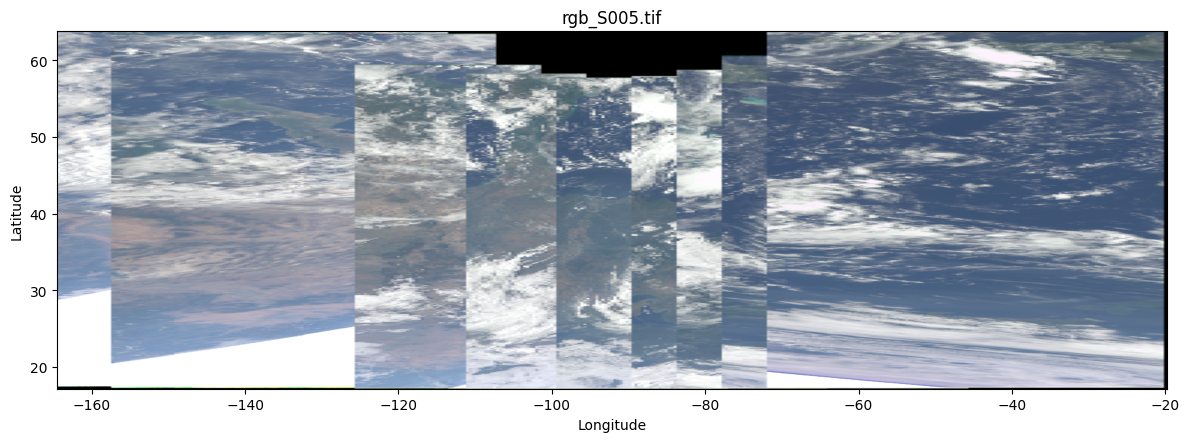

In [11]:
import matplotlib.pyplot as plt

# Pick the first merged scan we can find and plot the mosaic
tif_candidates = sorted(OUT_DIR.rglob("rgb_S*.tif"))
if not tif_candidates:
    print("No merged scans to preview yet.")
else:
    sample = tif_candidates[3]
    print(f"Previewing {sample}")
    with rasterio.open(str(sample)) as src:
        rgb = src.read()                     # (3, H, W)
        rgb = np.transpose(rgb, (1, 2, 0))   # (H, W, 3)
        bounds = src.bounds
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(rgb, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(sample.name)
    plt.tight_layout()
    plt.show()

## Notes and limitations

**Why this is a first-pass solution.** We are merging the *already-rasterized*
per-granule outputs, not the underlying L1B/L2 data. Each per-granule GeoTIFF
was written with its own `from_bounds(west, south, east, north, width, height)`
affine, so the pixel size in degrees differs slightly between granules. When
`rasterio.merge` mosaics them it picks the first source's resolution and
resamples the others to match. This is fine for visualization but does mean:

- Granule seams can show 1–2 pixel of subtle misalignment in the mosaic.
- Vector polygons are simply concatenated. A cloud that physically crosses a
  granule boundary will be represented as two adjacent polygons that share an
  edge but are not unioned. For analysis that needs dissolved geometries,
  apply `shapely.unary_union` or QGIS' Dissolve.

**What "correct" looks like.** A geometrically faithful scan-level pipeline
would (a) load the L1B/L2 granules belonging to one scan, (b) concatenate the
native `(mirror_step, xtrack)` arrays along the mirror_step axis to form a
full-scan grid, (c) run the DARCLOS-TEMPO algorithm once on that full grid,
and (d) write a single GeoTIFF and three shapefiles per scan from that
single-grid result. That removes the resampling step entirely and lets shadows
cast across granule boundaries be detected correctly (which they cannot be in
the per-granule pipeline today). Implementing it is the next step once this
exploratory mosaic version is validated visually.